In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import QuantileTransformer
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
scale = QuantileTransformer(n_quantiles=100, output_distribution='normal')

In [3]:
submisison = pd.read_csv('../../score/sample_submission.csv')

In [4]:
data1 = pd.read_csv('../../score/public_lb_9648.csv') # 0.9648
data2 = pd.read_csv('../../score/regress.csv') # 0.9548

In [5]:
data1['target'] = scale.fit_transform(data1[['target']])
data2['target'] = scale.fit_transform(data2[['target']])

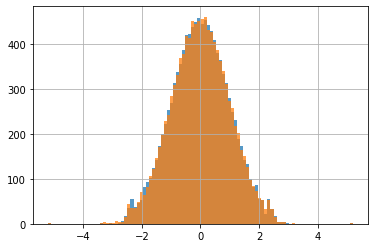

In [6]:
data1.target.hist(bins=100, alpha=0.75)
data2.target.hist(bins=100, alpha=0.75)

In [7]:
pd.DataFrame([data1.target, data2.target]).T.corr()

,target,target
target,1.00000,0.51982
target,0.51982,1.00000


In [8]:
data1['target'] = data1['target'].rank()
data2['target'] = data2['target'].rank()

In [9]:
pd.DataFrame([data1.target, data2.target]).T.corr()

,target,target
target,1.000000,0.497278
target,0.497278,1.000000


In [10]:
blend = data1.append(data2)
blend = blend.groupby('image_name').mean().reset_index()

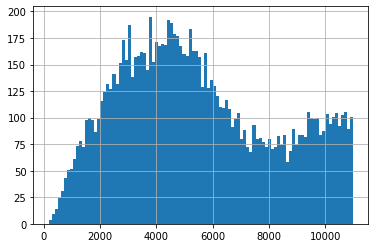

In [11]:
blend.target.hist(bins=100)

In [12]:
blend.to_csv('../../score/blend.csv', index=False)

In [13]:
# 0.9624